In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import kagglehub
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
df   = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")
print(f"Dataset shape: {df.shape}")
print(df["Diabetes_binary"].value_counts())

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Dataset shape: (253680, 22)
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


In [ ]:
# Fixed random undersample
df_diabetes    = df[df["Diabetes_binary"] == 1].reset_index(drop=True)
df_no_diabetes = df[df["Diabetes_binary"] == 0].reset_index(drop=True)
n_minority     = len(df_diabetes)

df_no_sample = df_no_diabetes.sample(n=n_minority, random_state=1)
df_balanced  = pd.concat([df_diabetes, df_no_sample]).sample(frac=1, random_state=1)

X_clf = df_balanced.drop(columns=["Diabetes_binary"]).values
y_clf = df_balanced["Diabetes_binary"].values

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=1, stratify=y_clf
)

scaler_clf    = StandardScaler()
X_clf_train_s = scaler_clf.fit_transform(X_clf_train)
X_clf_test_s  = scaler_clf.transform(X_clf_test)

print(f"Train size: {X_clf_train_s.shape}")
print(f"Test size : {X_clf_test_s.shape}")
print(f"Class balance - Train: {y_clf_train.mean():.2f} | Test: {y_clf_test.mean():.2f}")

Train size: (56553, 21)
Test size : (14139, 21)
Class balance - Train: 0.50 | Test: 0.50


In [ ]:
X_reg = df.drop(columns=["BMI", "Diabetes_binary"]).values
y_reg = df["BMI"].values

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=1
)

scaler_reg    = StandardScaler()
X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_test_s  = scaler_reg.transform(X_reg_test)

print(f"Regression Train size: {X_reg_train_s.shape}")
print(f"Regression Test size : {X_reg_test_s.shape}")

Regression Train size: (202944, 20)
Regression Test size : (50736, 20)


In [ ]:
class SimpleClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x).squeeze()


class DeepClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x).squeeze()


class SimpleRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x).squeeze()


class DeepRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.network(x).squeeze()

print("Models defined successfully!")

Models defined successfully!


In [ ]:
def train_classifier(model, X_train_s, y_train, X_test_s, epochs=100):
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_train,   dtype=torch.float32).to(device)
    X_te_t = torch.tensor(X_test_s,  dtype=torch.float32).to(device)

    dataset   = TensorDataset(X_tr_t, y_tr_t)
    loader    = DataLoader(dataset, batch_size=512, shuffle=True)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_loss   = float("inf")
    best_logits = None
    losses      = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        scheduler.step(avg_loss)

        if avg_loss < best_loss:
            best_loss = avg_loss
            model.eval()
            with torch.no_grad():
                best_logits = model(X_te_t).cpu().numpy()

    return losses, best_logits


def train_regressor(model, X_train_s, y_train, X_test_s, epochs=100):
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_train,   dtype=torch.float32).to(device)
    X_te_t = torch.tensor(X_test_s,  dtype=torch.float32).to(device)

    dataset   = TensorDataset(X_tr_t, y_tr_t)
    loader    = DataLoader(dataset, batch_size=512, shuffle=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_loss   = float("inf")
    best_preds  = None
    losses      = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        scheduler.step(avg_loss)

        if avg_loss < best_loss:
            best_loss = avg_loss
            model.eval()
            with torch.no_grad():
                best_preds = model(X_te_t).cpu().numpy()

    return losses, best_preds

print("Training helpers defined!")

Training helpers defined!


In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=1)
lr_model.fit(X_clf_train_s, y_clf_train)
y_pred_lr = lr_model.predict(X_clf_test_s)

print("=== Logistic Regression ===")
print(classification_report(y_clf_test, y_pred_lr, target_names=["No Diabetes", "Diabetes"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

 No Diabetes       0.76      0.72      0.74      7069
    Diabetes       0.73      0.77      0.75      7070

    accuracy                           0.74     14139
   macro avg       0.75      0.74      0.74     14139
weighted avg       0.75      0.74      0.74     14139



In [ ]:
simple_clf = SimpleClassifierNN(X_clf_train_s.shape[1]).to(device)
simple_clf_losses, simple_clf_logits = train_classifier(
    simple_clf, X_clf_train_s, y_clf_train, X_clf_test_s, epochs=100
)
y_pred_simple_clf = (simple_clf_logits > 0.5).astype(int)

print("=== Simple Classifier NN ===")
print(classification_report(y_clf_test, y_pred_simple_clf, target_names=["No Diabetes", "Diabetes"]))

=== Simple Classifier NN ===
              precision    recall  f1-score   support

 No Diabetes       0.70      0.81      0.75      7069
    Diabetes       0.78      0.65      0.71      7070

    accuracy                           0.73     14139
   macro avg       0.74      0.73      0.73     14139
weighted avg       0.74      0.73      0.73     14139



In [ ]:
deep_clf = DeepClassifierNN(X_clf_train_s.shape[1]).to(device)
deep_clf_losses, deep_clf_logits = train_classifier(
    deep_clf, X_clf_train_s, y_clf_train, X_clf_test_s, epochs=100
)
y_pred_deep_clf = (deep_clf_logits > 0.5).astype(int)

print("=== Deep Classifier NN ===")
print(classification_report(y_clf_test, y_pred_deep_clf, target_names=["No Diabetes", "Diabetes"]))

=== Deep Classifier NN ===
              precision    recall  f1-score   support

 No Diabetes       0.71      0.80      0.75      7069
    Diabetes       0.77      0.67      0.72      7070

    accuracy                           0.74     14139
   macro avg       0.74      0.74      0.73     14139
weighted avg       0.74      0.74      0.73     14139



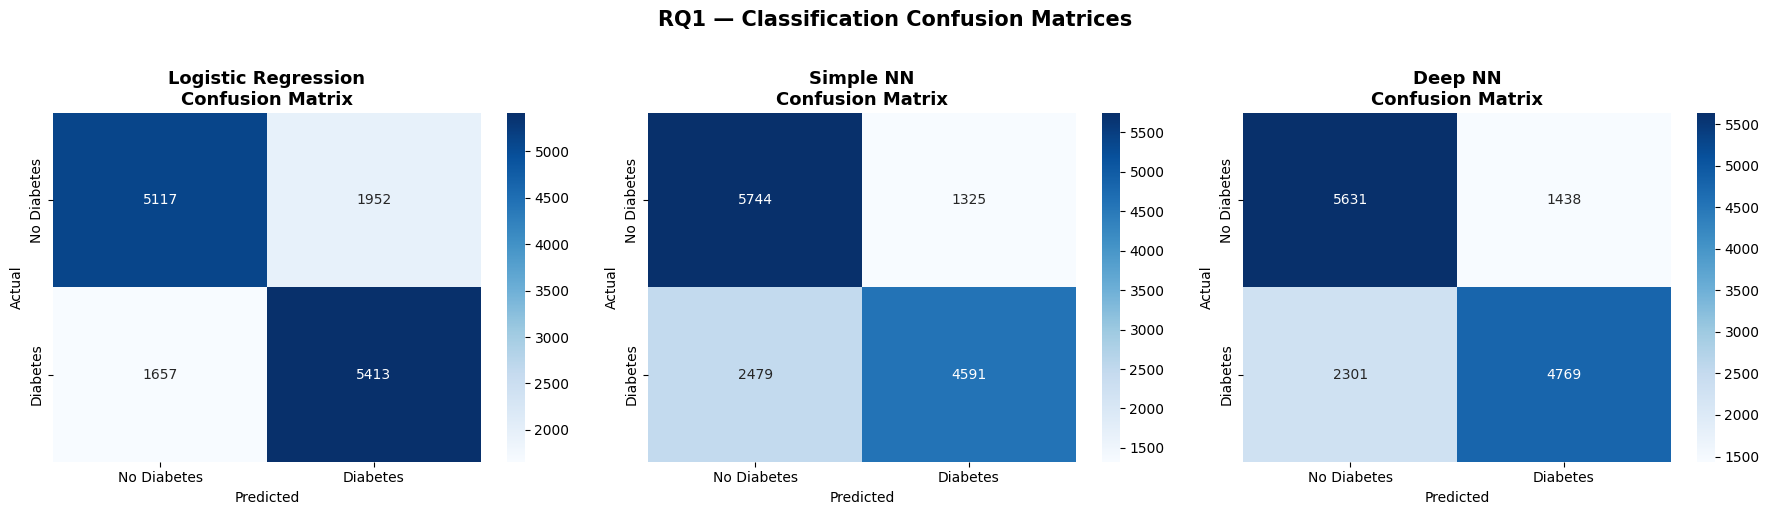

Saved: confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Simple NN",           y_pred_simple_clf),
    ("Deep NN",             y_pred_deep_clf),
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_clf_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("RQ1 — Classification Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

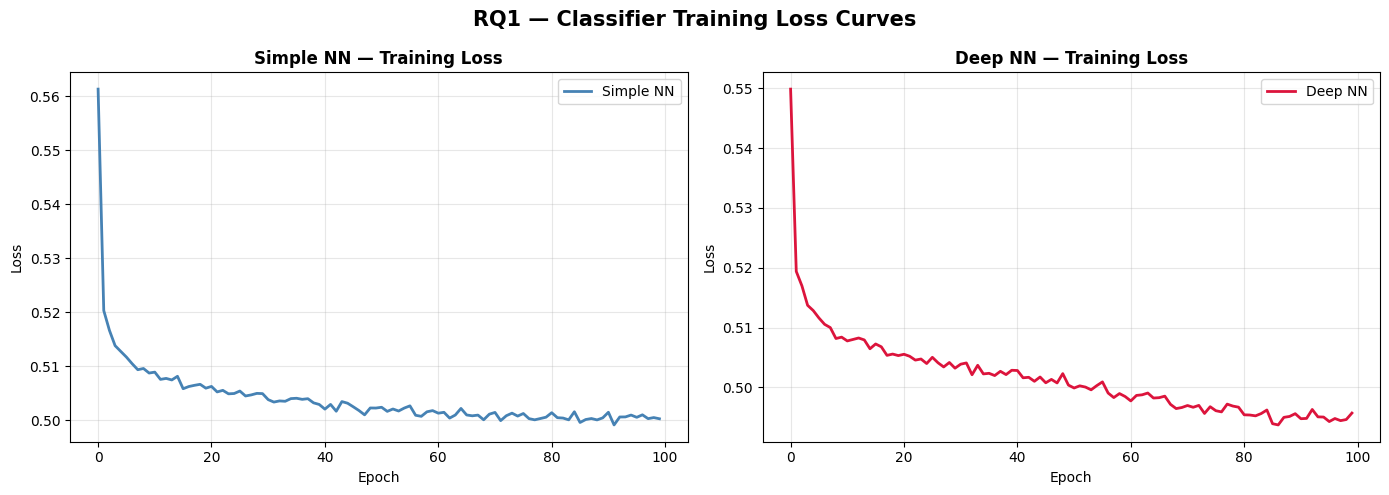

Saved: clf_loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(simple_clf_losses, color="steelblue", linewidth=2, label="Simple NN")
axes[0].set_title("Simple NN — Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(deep_clf_losses, color="crimson", linewidth=2, label="Deep NN")
axes[1].set_title("Deep NN — Training Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("RQ1 — Classifier Training Loss Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("clf_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: clf_loss_curves.png")

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_reg_train_s, y_reg_train)
y_pred_linreg = lin_reg.predict(X_reg_test_s)

print("=== Linear Regression ===")
print(f"MAE : {mean_absolute_error(y_reg_test, y_pred_linreg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_linreg)):.4f}")
print(f"R2  : {r2_score(y_reg_test, y_pred_linreg):.4f}")

=== Linear Regression ===
MAE : 4.4012
RMSE: 6.2506
R2  : 0.1193


In [ ]:
simple_reg = SimpleRegressorNN(X_reg_train_s.shape[1]).to(device)
simple_reg_losses, simple_reg_preds = train_regressor(
    simple_reg, X_reg_train_s, y_reg_train, X_reg_test_s, epochs=100
)

print("=== Simple Regressor NN ===")
print(f"MAE : {mean_absolute_error(y_reg_test, simple_reg_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, simple_reg_preds)):.4f}")
print(f"R2  : {r2_score(y_reg_test, simple_reg_preds):.4f}")

=== Simple Regressor NN ===
MAE : 4.2618
RMSE: 6.1049
R2  : 0.1599


In [ ]:
deep_reg = DeepRegressorNN(X_reg_train_s.shape[1]).to(device)
deep_reg_losses, deep_reg_preds = train_regressor(
    deep_reg, X_reg_train_s, y_reg_train, X_reg_test_s, epochs=100
)

print("=== Deep Regressor NN ===")
print(f"MAE : {mean_absolute_error(y_reg_test, deep_reg_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, deep_reg_preds)):.4f}")
print(f"R2  : {r2_score(y_reg_test, deep_reg_preds):.4f}")

=== Deep Regressor NN ===
MAE : 4.2255
RMSE: 6.1129
R2  : 0.1577


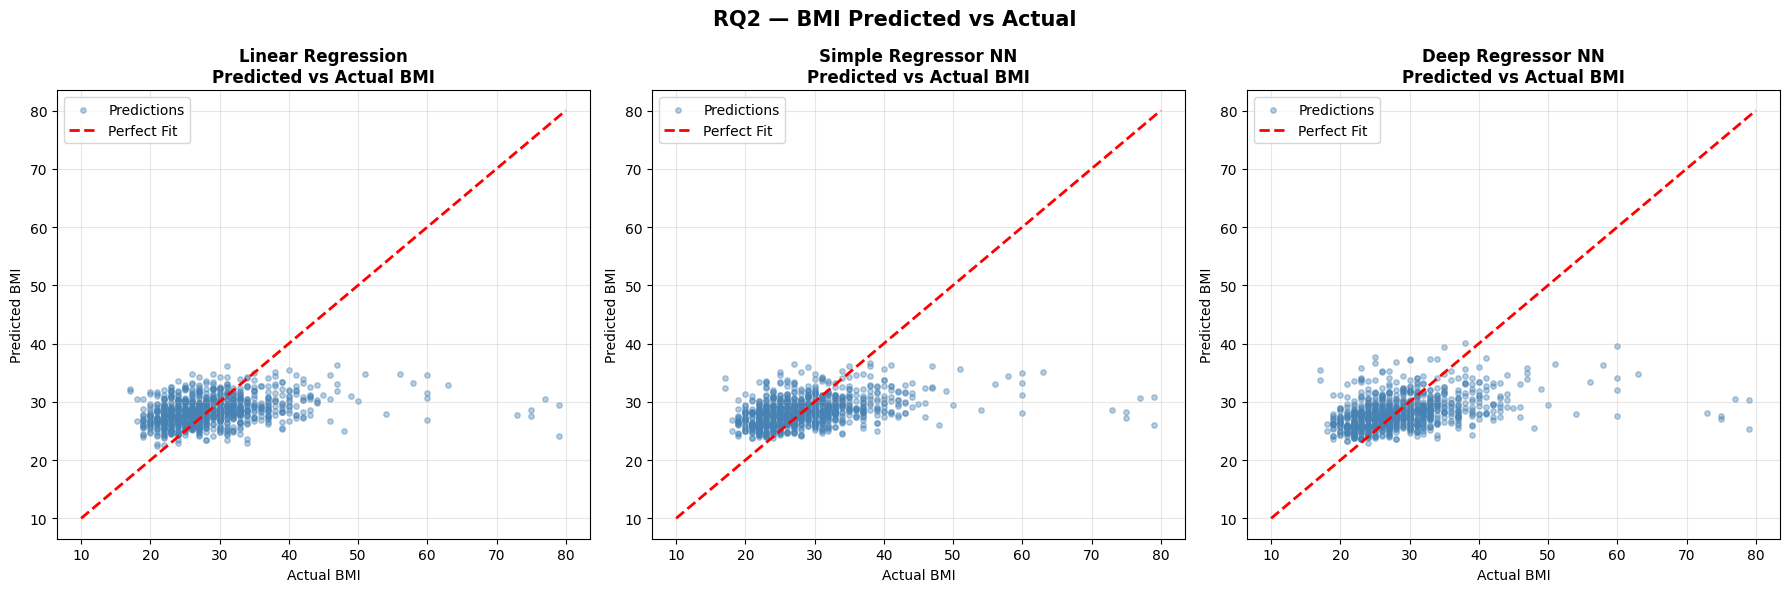

Saved: bmi_predicted_vs_actual.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_reg = [
    ("Linear Regression", y_pred_linreg),
    ("Simple Regressor NN", simple_reg_preds),
    ("Deep Regressor NN",   deep_reg_preds),
]

for ax, (name, preds) in zip(axes, models_reg):
    ax.scatter(y_reg_test[:1000], preds[:1000],
               alpha=0.4, color="steelblue", s=15, label="Predictions")
    ax.plot([10, 80], [10, 80], "r--", linewidth=2, label="Perfect Fit")
    ax.set_title(f"{name}\nPredicted vs Actual BMI", fontweight="bold")
    ax.set_xlabel("Actual BMI")
    ax.set_ylabel("Predicted BMI")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("RQ2 — BMI Predicted vs Actual", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("bmi_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bmi_predicted_vs_actual.png")

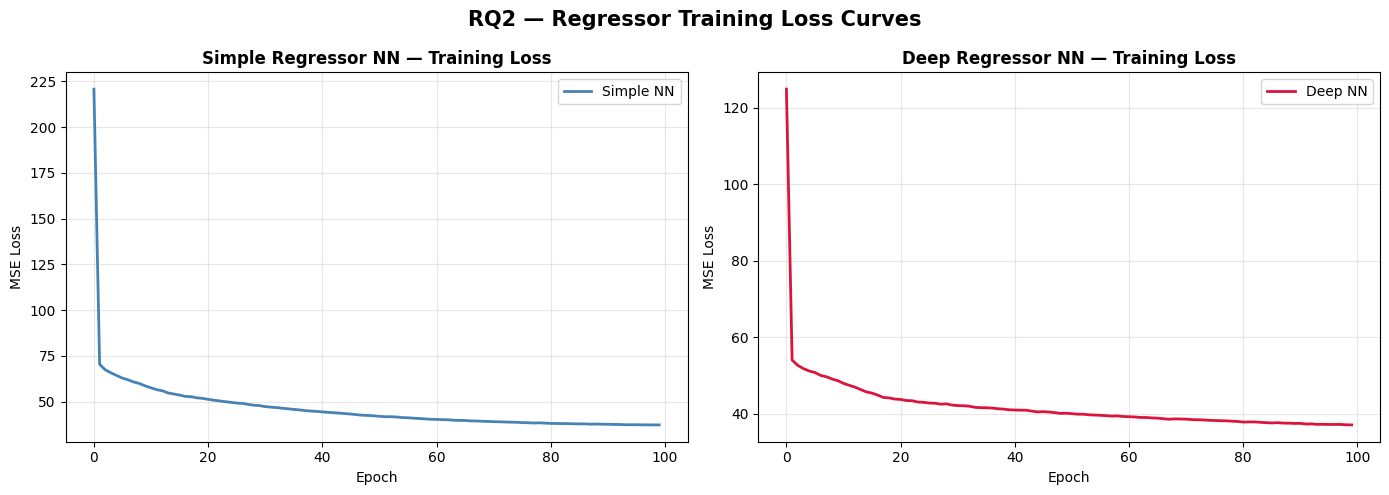

Saved: reg_loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(simple_reg_losses, color="steelblue", linewidth=2, label="Simple NN")
axes[0].set_title("Simple Regressor NN — Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(deep_reg_losses, color="crimson", linewidth=2, label="Deep NN")
axes[1].set_title("Deep Regressor NN — Training Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("RQ2 — Regressor Training Loss Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("reg_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reg_loss_curves.png")